In [ ]:
import torch
from src.model.gpt_model import GPTModel
# from GPT_CONFIG_124M import GPT_CONFIG_124M

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_featu

In [ ]:
import tiktoken
from src.inference.generate_text_simple import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) #add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    token_list = token_ids.squeeze(0).tolist() #as we will get a stacked tensor of shape (1, seq_len) we need to remove the batch dimension 
    return tokenizer.decode(token_list)

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))



Output text:
 Every effort moves you rentingetic minion cones477243 therepo expression syll


In [3]:
inputs = torch.tensor([[16833, 3626, 6100], # ["every effort moves",
                        [40, 1107, 588]])    # "I really like"]

targets = torch.tensor([[3626, 6100, 345 ], # [" effort moves you",
                        [107, 588, 11311]]) # " really like chocolate"]

In [4]:
with torch.no_grad():
    logits = model(inputs)
    # print("Logits shape:", logits.shape)  # Should be (batch_size, seq_len, vocab_size)

probas = torch.softmax(logits, dim=-1)
print("Probabilities shape:", probas.shape)  # Should be (batch_size, seq_len, vocab_size)

Probabilities shape: torch.Size([2, 3, 50257])


In [5]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Predicted token IDs:\n", token_ids)

Predicted token IDs:
 tensor([[[16657],
         [13866],
         [44376]],

        [[49906],
         [29669],
         [41751]]])


In [6]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Armedbage inaction


In [7]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4514e-05, 2.9619e-05, 1.2005e-05])
Text 2: tensor([3.9085e-05, 5.5137e-05, 5.1461e-06])


In [8]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print("Log Probabilities:", log_probas)

Log Probabilities: tensor([ -9.5045, -10.4271, -11.3302, -10.1498,  -9.8057, -12.1773])


In [9]:
avg_log_probas = torch.mean(log_probas)
print("Average Log Probability:", avg_log_probas)

Average Log Probability: tensor(-10.5658)


In [10]:
negative_avg_log_probas = avg_log_probas * -1
print("Negative Average Log Probability (Loss):", negative_avg_log_probas)

Negative Average Log Probability (Loss): tensor(10.5658)


In [11]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [12]:
logits_flat = logits.flatten(0,1) # (batch_size * seq_len, vocab_size)
targets_flat = targets.flatten() # (batch_size * seq_len,)
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [13]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat) # computes softmax, selects the corresponding target probabilities, takes the log and averages over the batch then multiplies by -1
print("Cross-Entropy Loss:", loss)

Cross-Entropy Loss: tensor(10.5658)


In [14]:
perplexity = torch.exp(loss)
print("Perplexity:", perplexity)

Perplexity: tensor(38783.5352)


In [15]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

In [16]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [17]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [ ]:
from src.data.data_loader import create_dataloader_v1
torch.manual_seed(123)

train_loader = create_dataloader_v1(train_data, batch_size=2, max_length=GPT_CONFIG_124M["context_length"], stride=GPT_CONFIG_124M["context_length"], shuffle=True, drop_last=True, num_workers=0 )

val_loader = create_dataloader_v1(val_data, batch_size=2, max_length=GPT_CONFIG_124M["context_length"], stride=GPT_CONFIG_124M["context_length"], shuffle=False, drop_last=False, num_workers=0 )

In [19]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)
print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [20]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    model = model.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())
    return loss

In [21]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches == None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.98767015669081
Validation loss: 10.980696678161621


In [23]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [24]:
def generate_and_print_sample(model, tokenizer, device, start_context): 
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(model=model, idx=encoded, max_new_tokens=50, context_size=context_size)
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " ")) # Compact print format
    model.train()

In [25]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    
    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel() # batch_size * seq_len
            global_step += 1
            
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")
                
        generate_and_print_sample(model, tokenizer, device, start_context)
    
    return train_losses, val_losses, track_tokens_seen

In [26]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1) 
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, 
    num_epochs=num_epochs, eval_freq=5, eval_iter=1,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 10.066, Val loss 9.929
Ep 1 (Step 000005): Train loss 8.158, Val loss 8.339
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.557, Val loss 7.051
Ep 2 (Step 000015): Train loss 5.927, Val loss 6.605
Every effort moves you, and,, and,,,,,,, and,.                                   
Ep 3 (Step 000020): Train loss 5.819, Val loss 6.501
Ep 3 (Step 000025): Train loss 5.373, Val loss 6.377
Every effort moves you, and to the to the of the picture. Gis, and I had. Gis, and, and, and, and, and I had, and, and, and, and, and, and, and, and, and,
Ep 4 (Step 000030): Train loss 4.555, Val loss 6.278
Ep 4 (Step 000035): Train loss 5.038, Val loss 6.329
Every effort moves you of the picture.      "I                "I"I the picture"I had the picture"I"I had the picture"I"I
Ep 5 (Step 000040): Train loss 4.020, Val loss 6.161
Every effort moves you know the        "Oh a me.             "Oh, and his pictures a little

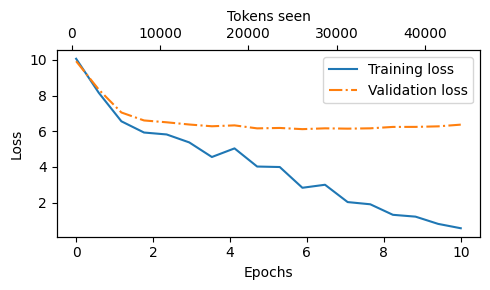

In [27]:
import matplotlib.pyplot as plt
def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax2 = ax1.twiny() 
    ax2.plot(tokens_seen, train_losses, alpha=0) 
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [28]:
model.to("cpu")
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_featu

In [29]:
tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




In [30]:
vocab = {
"closer": 0,
"every": 1,
"effort": 2,
"forward": 3,
"inches": 4,
"moves": 5,
"pizza": 6,
"toward": 7,
"you": 8,
}

inverse_vocab = {v: k for k, v in vocab.items()}

In [31]:
inverse_vocab

{0: 'closer',
 1: 'every',
 2: 'effort',
 3: 'forward',
 4: 'inches',
 5: 'moves',
 6: 'pizza',
 7: 'toward',
 8: 'you'}

In [32]:
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

In [33]:
probas = torch.softmax(next_token_logits, axis=-1)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

forward


In [34]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [35]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    samples = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(samples))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [36]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits/temperature
    return torch.softmax(scaled_logits, dim=0)

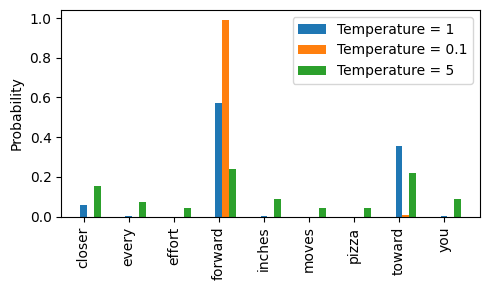

In [37]:
# Temperatures greater than 1 result in more uniformly distributed token probabilities,
# and Temperatures smaller than 1 will result in more confident (sharper or more peaky)
# distributions. Let's illustrate this by plotting the original probabilities alongside
# probabilities scaled with different temperature values:

temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, temperature) for temperature in temperatures]

x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))

for i, T in enumerate(temperatures):
    rects = ax.bar(
        x + i * bar_width,
        scaled_probas[i],
        bar_width,
        label=f'Temperature = {T}'
    )

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()
plt.tight_layout()
plt.show()


In [38]:
len(vocab)

9

In [39]:
torch.softmax(next_token_logits/5, dim=0)

tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])

In [40]:
torch.softmax(next_token_logits, dim=0)

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])

In [41]:
for probas in scaled_probas:
    print_sampled_tokens(probas)
    print("\n\n")

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward



0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward



165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you





In [42]:
pizza_index = vocab["pizza"]
print(probas[pizza_index])

tensor(0.0430)


In [43]:
for probas in scaled_probas:
    print(f"pizza: {probas[pizza_index].item() * 1_000}")
    print("\n\n")

pizza: 0.10120050137629732



pizza: 2.971829782368292e-35



pizza: 42.99796372652054





In [44]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


In [45]:
new_logits = torch.where(
    condition=next_token_logits<top_logits[-1], # Compare with the lowest logit in the top-k
    input = torch.tensor(float("-inf")), # Set to -inf if condition is true
    other = next_token_logits # Keep original logit if condition is false
)

print("New logits after top-k filtering:", new_logits)

New logits after top-k filtering: tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [46]:
topk_probas = torch.softmax(new_logits, dim=-1)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [47]:
def generate(model, idx, max_new_tokens, context_size, temperature = 1.0, top_k = None, eos_id = None):

    for _ in range(max_new_tokens):
        idx_trimmed = idx[:, -context_size:] # Trim context to fit within model's context size
        
        with torch.no_grad():
            logits = model(idx_trimmed)
        
        logits = logits[:,-1,:] # Get logits for the last token in the sequence
    
        if top_k is not None:
            top_k_logits, _ = torch.topk(logits, top_k)
            min_top_k_logit = top_k_logits[:,-1] # Get the lowest logit in the top-k for each batch item
            logits = torch.where(
                condition = logits < min_top_k_logit, # Compare with the lowest logit in the top-k
                input = torch.tensor(float("-inf")).to(logits.device), # Set to -inf if condition is true
                other=logits # Keep original logit if condition is false
            )
        
        if temperature > 0.0:
            logits = logits/temperature
            probas = torch.softmax(logits, dim=-1)
            next_token_id = torch.multinomial(probas, num_samples=1)
        
        else:
            next_token_id = torch.argmax(logits, dim=-1, keepdim=True)
        
        if eos_id == None:
            idx = torch.cat([idx, next_token_id], dim=-1)
        
        else:
            break
        
    return idx
    

In [50]:
torch.manual_seed(123)

model = model.to(device)

token_ids = generate(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens = 15,
    context_size = GPT_CONFIG_124M["context_length"],
    temperature=1.4 
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as studio accompaniesrow ConfederadvantAnnaenezYes-- 10000 reply Mrs. Doyle


In [51]:
torch.manual_seed(123)

token_ids = generate(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens = 15,
    context_size = GPT_CONFIG_124M["context_length"],
    temperature=0.7 
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as studio him down."
I glanced after him, with a curious of


In [52]:
torch.manual_seed(123)

token_ids = generate(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens = 15,
    context_size = GPT_CONFIG_124M["context_length"],
    temperature=1.4,
    top_k=3 
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know."
"Oh, you know it--I looked up his last


In [53]:
torch.manual_seed(123)

token_ids = generate(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens = 15,
    context_size = GPT_CONFIG_124M["context_length"],
    temperature=0.7,
    top_k=5 
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you know terrace.

I glanced after him, with a me in


In [54]:
torch.manual_seed(123)

token_ids = generate(
    model = model,
    idx = text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens = 15,
    context_size = GPT_CONFIG_124M["context_length"],
    temperature=0.0,
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted


In [55]:
torch.save(model.state_dict(), "model.pth")

In [56]:
model_lodaded = GPTModel(GPT_CONFIG_124M)
model_lodaded.load_state_dict(torch.load("model.pth"))
model_lodaded.eval

<bound method Module.eval of GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
   

In [57]:
torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [58]:
checkpoint = torch.load("model_and_optimizer.pth")
model_lodaded_2 = GPTModel(GPT_CONFIG_124M)
model_lodaded_2.load_state_dict(checkpoint["model_state_dict"])
optimizer_loaded_2 = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer_loaded_2.load_state_dict(checkpoint["optimizer_state_dict"])
model_lodaded_2.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_featu

In [59]:
train_losses, val_losses, tokens_seen = train_model_simple(
    model_lodaded_2, train_loader, val_loader, optimizer_loaded_2, device, 
    num_epochs=1, eval_freq=5, eval_iter=1,
    start_context="Every effort moves you", tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 0.580, Val loss 6.426
Ep 1 (Step 000005): Train loss 0.468, Val loss 6.426
Every effort moves you?"  "Yes--quite insensible to the irony. She wanted him vindicated--and by me!"  He laughed again, and threw back his head to look up at the sketch of the donkey. "There were days when I


In [60]:
import urllib.request
url = (
"https://raw.githubusercontent.com/rasbt/"
"LLMs-from-scratch/main/ch05/"
"01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x1b4ff8453f0>)

In [ ]:
from gpt_download import download_and_load_gpt2

settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")

File already exists and is up-to-date: gpt2\124M\checkpoint
File already exists and is up-to-date: gpt2\124M\encoder.json
File already exists and is up-to-date: gpt2\124M\hparams.json
File already exists and is up-to-date: gpt2\124M\model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2\124M\model.ckpt.index
File already exists and is up-to-date: gpt2\124M\model.ckpt.meta
File already exists and is up-to-date: gpt2\124M\vocab.bpe


In [62]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())

#Parameters

#wte - word token embeddings i.e. the token embedding weight tensor that we can use to initialize our model's token embedding layer with the same weights as the original GPT-2 model

#wpe - word position embeddings i.e. the position embedding weight tensor that we can use to initialize our model's position embedding layer with the same weights as the original GPT-2 model

#blocks - a list of dictionaries containing the weights for each of the transformer blocks in the original GPT-2 model. We can use these to initialize the corresponding transformer blocks in our model with the same weights as the original GPT-2 model.

#g - Layer Norm Scale gamma weights for the final layer normalization in the original GPT-2 model. We can use these to initialize the corresponding layer normalization in our model with the same weights as the original GPT-2 model. It controls magnitudes of the activations after the final layer normalization.

#b - Layer Norm Bias beta weights for the final layer normalization in the original GPT-2 model. We can use these to initialize the corresponding layer normalization in our model with the same weights as the original GPT-2 model. It controls the shift of the activations after the final layer normalization.

# g and b are important for the model's output distribution as they control the magnitudes and shifts of the activations after the final layer normalization, which can affect the model's predictions and overall performance.


Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [63]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [64]:
# dictionary that lists the differences between the different GPT model sizes,

model_configs = {
"gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
"gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
"gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
"gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [65]:
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 256,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [66]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

In [67]:
NEW_CONFIG

{'vocab_size': 50257,
 'context_length': 256,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [68]:
# we used a 256-token length earlier, but the original
# GPT-2 models from OpenAI were trained with a 1,024-token length, so we have to update
# the NEW_CONFIG

NEW_CONFIG.update({"context_length": 1024})

# OpenAI used bias vectors in the multi-head attention module's linear layers to
# implement the query, key, and value matrix computations. Bias vectors are not commonly
# used in LLMs anymore as they don't improve the modeling performance and are thus
# unnecessary. However, since we are working with pretrained weights, we need to match the
# settings for consistency and enable these bias vectors in our model's multi-head attention module. So we also need
# to update the NEW_CONFIG to set "qkv_bias" to True

NEW_CONFIG.update({"qkv_bias": True})

In [69]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (transformer_blocks): Sequential(
    (0): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (ffn): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (attn): MultiHeadAttention(
        (W_key): Linear(in_feature

In [87]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    # return torch.nn.Parameter(torch.tensor(right).to(device))
    return torch.nn.Parameter(torch.from_numpy(right).to(device))

In [88]:
import numpy as np
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe']) # Setting the model's positional and token embedding weights to those specified in params.
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])): # Iterate over each transformer block in the model.
        
        # The np.split function is used to divide the attention and bias weights into three equal parts for the query,key, and value components.
        
        q_w, k_w, v_w = np.split((params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        
        gpt.transformer_blocks[b].attn.W_query.weight = assign(
            gpt.transformer_blocks[b].attn.W_query.weight, q_w.T)
        gpt.transformer_blocks[b].attn.W_key.weight = assign(
            gpt.transformer_blocks[b].attn.W_key.weight, k_w.T)
        gpt.transformer_blocks[b].attn.W_value.weight = assign(
            gpt.transformer_blocks[b].attn.W_value.weight, v_w.T)
        
        q_b, k_b, v_b = np.split((params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        
        gpt.transformer_blocks[b].attn.W_query.bias = assign(
            gpt.transformer_blocks[b].attn.W_query.bias, q_b)
        gpt.transformer_blocks[b].attn.W_key.bias = assign(
            gpt.transformer_blocks[b].attn.W_key.bias, k_b)
        gpt.transformer_blocks[b].attn.W_value.bias = assign(
            gpt.transformer_blocks[b].attn.W_value.bias, v_b)
        
        gpt.transformer_blocks[b].attn.out_proj.weight = assign(
            gpt.transformer_blocks[b].attn.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.transformer_blocks[b].attn.out_proj.bias = assign(
            gpt.transformer_blocks[b].attn.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])
        
        gpt.transformer_blocks[b].ffn.layers[0].weight = assign(
            gpt.transformer_blocks[b].ffn.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.transformer_blocks[b].ffn.layers[0].bias = assign(
            gpt.transformer_blocks[b].ffn.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.transformer_blocks[b].ffn.layers[2].weight = assign(
            gpt.transformer_blocks[b].ffn.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.transformer_blocks[b].ffn.layers[2].bias = assign(
            gpt.transformer_blocks[b].ffn.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        
        gpt.transformer_blocks[b].norm1.scale = assign(
            gpt.transformer_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.transformer_blocks[b].norm1.shift = assign(
            gpt.transformer_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        
        gpt.transformer_blocks[b].norm2.scale = assign(
            gpt.transformer_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.transformer_blocks[b].norm2.shift = assign(
            gpt.transformer_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])
    
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"]) #The original GPT-2 model by OpenAI reused the token embedding weights in the output layer to reduce the total number of parameters, which is a concept known as weight tying.


In [89]:
gpt.to(device)
load_weights_into_gpt(gpt, params)

In [99]:
torch.manual_seed(123)

token_ids = generate(
    model = gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle


In [100]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, gpt, device)
    val_loss = calc_loss_loader(val_loader, gpt, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.754627333747016
Validation loss: 3.559617042541504


In [ ]:
# from gpt_download import download_and_load_gpt2

# settings, params = download_and_load_gpt2(model_size="1558M", models_dir="gpt2") 

# check, ig openai may have changed how their models are named

Primary URL (https://openaipublic.blob.core.windows.net/gpt-2/models\1558M\checkpoint) failed. Attempting backup URL: https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2\1558M\checkpoint
Failed to download from both primary URL (https://openaipublic.blob.core.windows.net/gpt-2/models\1558M\checkpoint) and backup URL (https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2\1558M\checkpoint).
Check your internet connection or the file availability.
For help, visit: https://github.com/rasbt/LLMs-from-scratch/discussions/273
Primary URL (https://openaipublic.blob.core.windows.net/gpt-2/models\1558M\encoder.json) failed. Attempting backup URL: https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2\1558M\encoder.json
Failed to download from both primary URL (https://openaipublic.blob.core.windows.net/gpt-2/models\1558M\encoder.json) and backup URL (https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2\1558M\encoder.json).
Check your internet connection or the file availability.
Fo

FileNotFoundError: [Errno 2] No such file or directory: 'gpt2\\1558M\\hparams.json'